In [1]:
pip install qiskit qiskit-aer matplotlib numpy scipy

Note: you may need to restart the kernel to use updated packages.


Variational Quantum Eigensolver (VQE)

What is VQE?
VQE finds the minimum energy (ground state) of a quantum system.

Quantum computer  → prepares ansatz + measures energy
Classical optimizer → adjusts parameters to minimize energy

The Loop:
Random params → Quantum circuit → Measure energy
→ Classical optimizer → Update params → Repeat → Ground state!

Minimize energy of a simple 1-qubit system
Hamiltonian: H = Z (Pauli-Z operator)
Ground state energy = -1.0

In [2]:
#Imports
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import os
from dotenv import load_dotenv

load_dotenv()

simulator = AerSimulator()
os.makedirs("../results", exist_ok=True)

print("imports done")
print("scipy optimizer ready")
print("VQE simulation starting...")

imports done
scipy optimizer ready
VQE simulation starting...


Step 1: Build the Ansatz (Parameterized Circuit)

The ansatz is a parameterized quantum circuit.
Think of it as the "model architecture" in ML.

We use a single RY gate — rotates qubit by angle θ:
RY(0)   → |0⟩  (north pole)
RY(π)   → |1⟩  (south pole)
RY(π/2) → |+⟩  (equator = superposition)

Goal - find θ that gives minimum energy!

In [3]:
# Cell 4 - Build Parameterized Ansatz
def build_ansatz(theta):
    qc = QuantumCircuit(1)
    qc.ry(theta, 0)
    return qc

# test with 3 different angles
test_angles = [0, np.pi/2, np.pi]
labels = ['|0⟩ (theta=0)', '|+⟩ (theta=π/2)', '|1⟩ (theta=π)']

print("Ansatz circuit at different parameters:")
print("─────────────────────────────────────")
for angle, label in zip(test_angles, labels):
    qc = build_ansatz(angle)
    print(f"\ntheta = {label}")
    print(qc.draw())

Ansatz circuit at different parameters:
─────────────────────────────────────

theta = |0⟩ (theta=0)
   ┌───────┐
q: ┤ Ry(0) ├
   └───────┘

theta = |+⟩ (theta=π/2)
   ┌─────────┐
q: ┤ Ry(π/2) ├
   └─────────┘

theta = |1⟩ (theta=π)
   ┌───────┐
q: ┤ Ry(π) ├
   └───────┘


Step 2: Compute Energy (Expectation Value)

For Hamiltonian H = Z (Pauli-Z):
Energy = ⟨ψ|Z|ψ⟩ = probability(|0⟩) - probability(|1⟩)

If qubit is |0⟩ → energy = +1.0 (maximum)
If qubit is |1⟩ → energy = -1.0 (minimum = ground state!)
If superposition → energy = 0.0

Goal: find θ that gives energy = -1.0

In [4]:
# Cell 6 - Compute Energy
def compute_energy(theta):
    qc = build_ansatz(theta)
    qc.measure_all()

    counts = simulator.run(qc, shots=1000).result().get_counts()

    prob_0 = counts.get('0', 0) / 1000
    prob_1 = counts.get('1', 0) / 1000

    # expectation value of Z
    energy = prob_0 - prob_1
    return energy

# test energy at different angles
print("Energy at different theta values:")
print("──────────────────────────────────")
for angle, label in zip(test_angles, labels):
    energy = compute_energy(angle)
    print(f"theta={label:20s} energy = {energy:.3f}")

print("\nTarget: energy = -1.0 (ground state)")

Energy at different theta values:
──────────────────────────────────
theta=|0⟩ (theta=0)        energy = 1.000
theta=|+⟩ (theta=π/2)      energy = -0.014
theta=|1⟩ (theta=π)        energy = -1.000

Target: energy = -1.0 (ground state)


Step 3: Classical Optimizer

Now we let scipy's optimizer find the minimum energy
automatically — without us manually testing angles.

This is exactly what VQE does in real quantum chemistry!
Optimizer starts at random theta → finds ground state.

In [5]:
# Cell 8 - VQE Optimization
energy_history = []

def vqe_objective(params):
    energy = compute_energy(params[0])
    energy_history.append(energy)
    return energy

# start from random angle
initial_theta = [np.random.uniform(0, 2*np.pi)]
print(f"Starting theta: {initial_theta[0]:.3f} radians")
print(f"Starting energy: {compute_energy(initial_theta[0]):.3f}")
print("\nOptimizer running...")

# run classical optimizer
result = minimize(
    vqe_objective,
    initial_theta,
    method='COBYLA',
    options={'maxiter': 100}
)

print(f"\nOptimization complete!")
print(f"Optimal theta : {result.x[0]:.4f} radians")
print(f"Minimum energy: {result.fun:.4f}")
print(f"Iterations    : {len(energy_history)}")
print(f"Ground state  : -1.0")
print(f"Converged     : {abs(result.fun - (-1.0)) < 0.05}")

Starting theta: 2.990 radians
Starting energy: -0.992

Optimizer running...

Optimization complete!
Optimal theta : 3.1772 radians
Minimum energy: -1.0000
Iterations    : 14
Ground state  : -1.0
Converged     : True


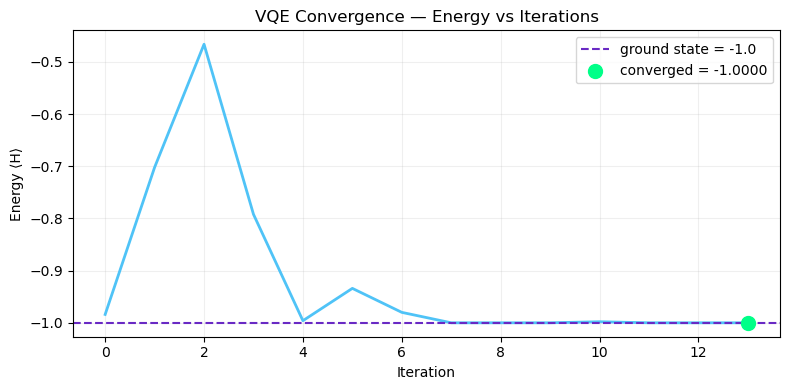

convergence plot saved


In [6]:
# Cell 9 - Plot convergence curve
plt.figure(figsize=(8, 4))
plt.plot(energy_history, color='#4fc3f7', linewidth=2)
plt.axhline(y=-1.0, color='#6929C4', linestyle='--',
            linewidth=1.5, label='ground state = -1.0')
plt.scatter(len(energy_history)-1, energy_history[-1],
            color='#00ff88', s=100, zorder=5,
            label=f'converged = {energy_history[-1]:.4f}')

plt.title("VQE Convergence — Energy vs Iterations")
plt.xlabel("Iteration")
plt.ylabel("Energy ⟨H⟩")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig("../results/vqe_convergence.png",
            facecolor='#1a1a2e')
plt.show()
print("convergence plot saved")

Results & Conclusion

| Parameter | Value |
|-----------|-------|
| Starting theta | 2.990 radians (random) |
| Optimal theta | 3.1772 radians (~π) |
| Starting energy | -0.992 |
| Final energy | -1.0000 |
| Iterations | 14 |
| Converged | True |

## Key Takeaways:
- Ansatz (RY gate) = parameterized quantum circuit
- Energy = expectation value of Pauli-Z operator
- COBYLA optimizer found ground state in 14 steps
- Optimal theta = π → qubit at south pole = |1⟩
- This is exactly how VQE works in quantum chemistry!
- Real applications: H2 molecule, LiH, drug discovery